In [7]:
#download the lm_results.csv file from the Rmd output and load it into a dataframe
import pandas as pd 
lm_res_df = pd.read_csv("/home/fgsasse_lrs_1/Downloads/BA/BA_data/Rmd_n_notebook/gene_peak_lm_ct_results.csv")

In [ ]:
lm_res_df.head()
lm_res_df.padj.max()


np.float64(0.49051107203130245)

window      100kb    10kb    20kb    50kb
threshold                                
0.001      0.0335  0.1174  0.0861  0.0534
0.010      0.0647  0.1896  0.1463  0.0973
0.050      0.1157  0.2818  0.2286  0.1626
0.100      0.1585  0.3425  0.2859  0.2128
0.200      0.2307  0.4315  0.3732  0.2932


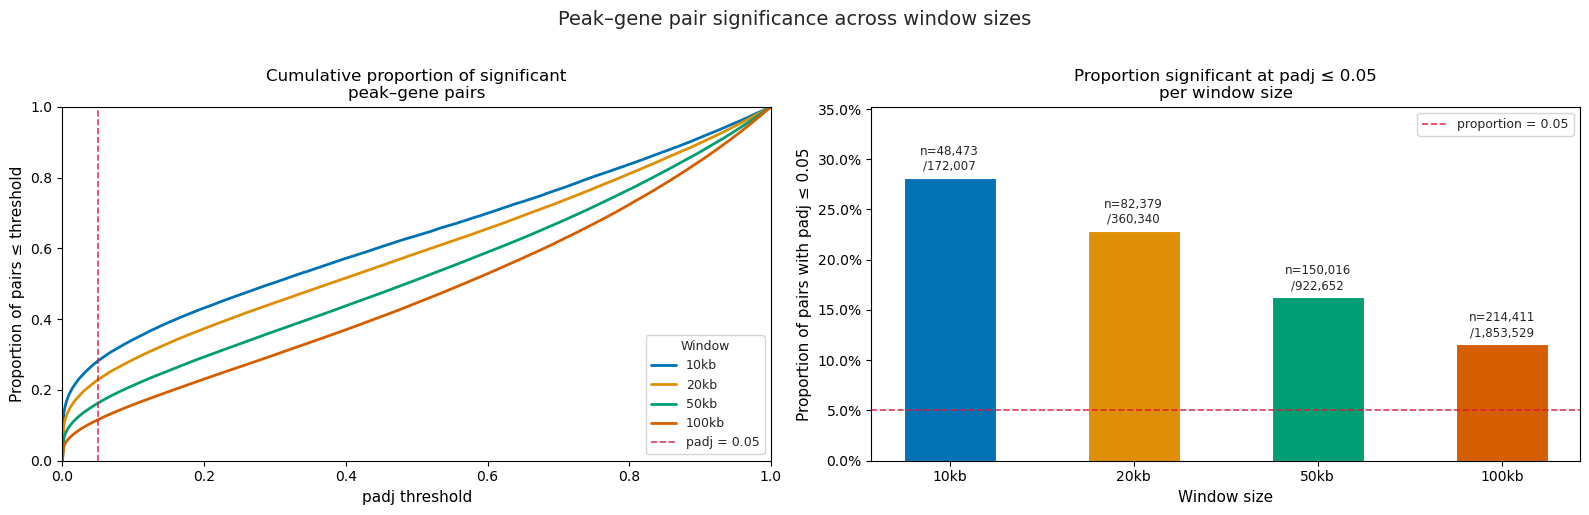

In [23]:
#Plotting the proportion of significant correlations (padj < 0.05) for each window size
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# 1. Continuous proportion curve across thresholds 
thresholds   = np.linspace(0, 1, 500)          # padj thresholds from 0 to 1
window_labels = ["10kb", "20kb", "50kb", "100kb"]

# build a tidy table: one row per (window, threshold)
prop_records = []
for window_label in window_labels:
    subset = lm_res_df[lm_res_df["window"] == window_label]["padj"].dropna()
    n_total = len(subset)
    if n_total == 0:
        continue
    for t in thresholds:
        prop = (subset <= t).sum() / n_total
        prop_records.append({
            "window":    window_label,
            "threshold": t,
            "proportion": prop,
            "n_total":   n_total,
        })

prop_df = pd.DataFrame(prop_records)

# 2. Summary table at biologically meaningful cutoffs 
cutoffs = [0.001, 0.01, 0.05, 0.1, 0.2]
summary_records = []
for window_label in window_labels:
    subset = lm_res_df[lm_res_df["window"] == window_label]["padj"].dropna()
    n_total = len(subset)
    for t in cutoffs:
        n_sig  = (subset <= t).sum()
        prop   = n_sig / n_total if n_total > 0 else np.nan
        summary_records.append({
            "window":     window_label,
            "threshold":  t,
            "n_total":    n_total,
            "n_sig":      n_sig,
            "proportion": prop,
        })

summary_df = pd.DataFrame(summary_records)
print(summary_df.pivot(index="threshold", columns="window", values="proportion")
                .round(4)
                .to_string())

# 3. Plot 
palette = sns.color_palette("colorblind", n_colors=len(window_labels))
color_map = dict(zip(window_labels, palette))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.set_style("whitegrid")

# --- left panel: full proportion curve ---------------------------------------
ax = axes[0]
for window_label in window_labels:
    wdf = prop_df[prop_df["window"] == window_label]
    ax.plot(
        wdf["threshold"], wdf["proportion"],
        label=window_label,
        color=color_map[window_label],
        linewidth=2.0
    )

ax.axvline(0.05, color="crimson", linestyle="--",
           linewidth=1.2, alpha=0.85, label="padj = 0.05")
ax.set_xlabel("padj threshold", fontsize=11)
ax.set_ylabel("Proportion of pairs ≤ threshold", fontsize=11)
ax.set_title("Cumulative proportion of significant\npeak–gene pairs", fontsize=12)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.legend(title="Window", fontsize=9, title_fontsize=9)

# --- right panel: bar chart at fixed cutoffs ---------------------------------
ax = axes[1]
bar_df = summary_df[summary_df["threshold"] == 0.05].copy()
bars = ax.bar(
    bar_df["window"],
    bar_df["proportion"],
    color=[color_map[w] for w in bar_df["window"]],
    edgecolor="white",
    linewidth=0.8,
    width=0.5
)

# annotate bars with absolute counts
for bar, (_, row) in zip(bars, bar_df.iterrows()):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.005,
        f"n={int(row['n_sig']):,}\n/{int(row['n_total']):,}",
        ha="center", va="bottom", fontsize=8.5
    )

ax.axhline(0.05, color="crimson", linestyle="--",
           linewidth=1.2, alpha=0.85, label="proportion = 0.05")
ax.set_xlabel("Window size", fontsize=11)
ax.set_ylabel("Proportion of pairs with padj ≤ 0.05", fontsize=11)
ax.set_title("Proportion significant at padj ≤ 0.05\nper window size", fontsize=12)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=1))
ax.set_ylim(0, bar_df["proportion"].max() * 1.25)
ax.legend(fontsize=9)

fig.suptitle("Peak–gene pair significance across window sizes", y=1.02, fontsize=14)
plt.tight_layout()

fig.savefig(
    "/home/fgsasse_lrs_1/Downloads/BA/BA_data/Correlations/Graphics/"
    "peak_gene_proportion_significant_ct.png",
    dpi=300, bbox_inches="tight"
)
plt.show()

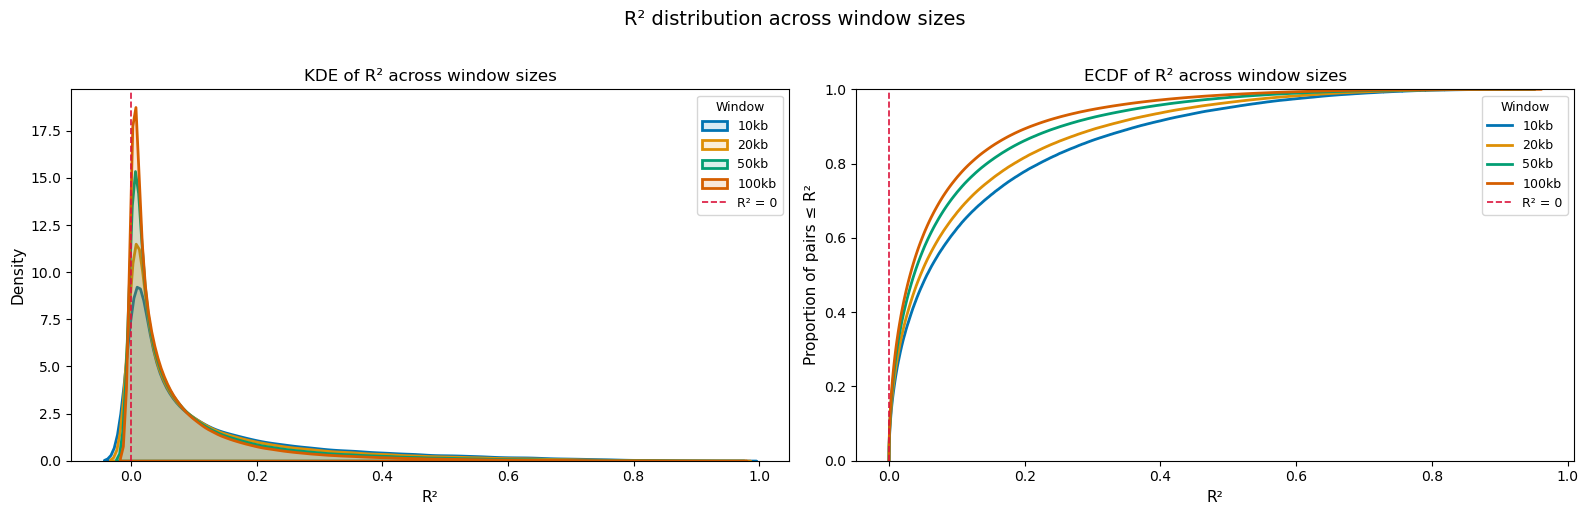

In [3]:
## Plotting R² distribution across windows
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns

window_labels = ["10kb", "20kb", "50kb", "100kb"]

#set xlim 
# ── KDE + ECDF combined figure ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
palette = sns.color_palette("colorblind", n_colors=4)

# --- left panel: KDE ----------------------------------------------------------
ax_kde = axes[0]
for color, window_label in zip(palette, window_labels):
    subset = lm_res_df[lm_res_df["window"] == window_label]["r_squared"].dropna()
    sns.kdeplot(subset, ax=ax_kde, label=window_label, color=color,
                linewidth=2.0, fill=True, alpha=0.15)

ax_kde.axvline(0.0, color="crimson", linestyle="--", linewidth=1.2, label="R² = 0")
ax_kde.set_xlabel("R²", fontsize=11)
ax_kde.set_ylabel("Density", fontsize=11)
ax_kde.set_title("KDE of R² across window sizes", fontsize=12)
ax_kde.legend(title="Window", fontsize=9, title_fontsize=9)

# --- right panel: ECDF --------------------------------------------------------
ax_ecdf = axes[1]
for color, window_label in zip(palette, window_labels):
    subset = lm_res_df[lm_res_df["window"] == window_label]["r_squared"].dropna()
    sns.ecdfplot(subset, ax=ax_ecdf, label=window_label, color=color, linewidth=2.0)

ax_ecdf.axvline(0.0, color="crimson", linestyle="--", linewidth=1.2, label="R² = 0")
ax_ecdf.set_xlabel("R²", fontsize=11)
ax_ecdf.set_ylabel("Proportion of pairs ≤ R²", fontsize=11)
ax_ecdf.set_title("ECDF of R² across window sizes", fontsize=12)
ax_ecdf.legend(title="Window", fontsize=9, title_fontsize=9)

fig.suptitle("R² distribution across window sizes", y=1.02, fontsize=14)
plt.tight_layout()

fig.savefig(
    "/home/fgsasse_lrs_1/Downloads/BA/BA_data/Correlations/Graphics/"
    "peak_gene_r_squared_kde_ecdf_ct.png",
    dpi=300, bbox_inches="tight"
)
plt.show()

KDE: shows r^2 distribution shape in each window
- r^2 peak near 0 increasing by larger window size means added peaks have almost no explanatory power
- right tail is a subset of peaks that are strong regulators
- shrinking right tail by increasing window size means distal peaks are weaker regulators

ECDF: shows how much fraction of peak-gene pairs falls into any r^2-threshold
- the proportion of R^2 in the lower region (<= 0.2) increases exponentially by larger window sizes, indicating dilution of (distal) peaks with almost no/very low explanatory power; diluted by a growing background of non-regulatory peaks

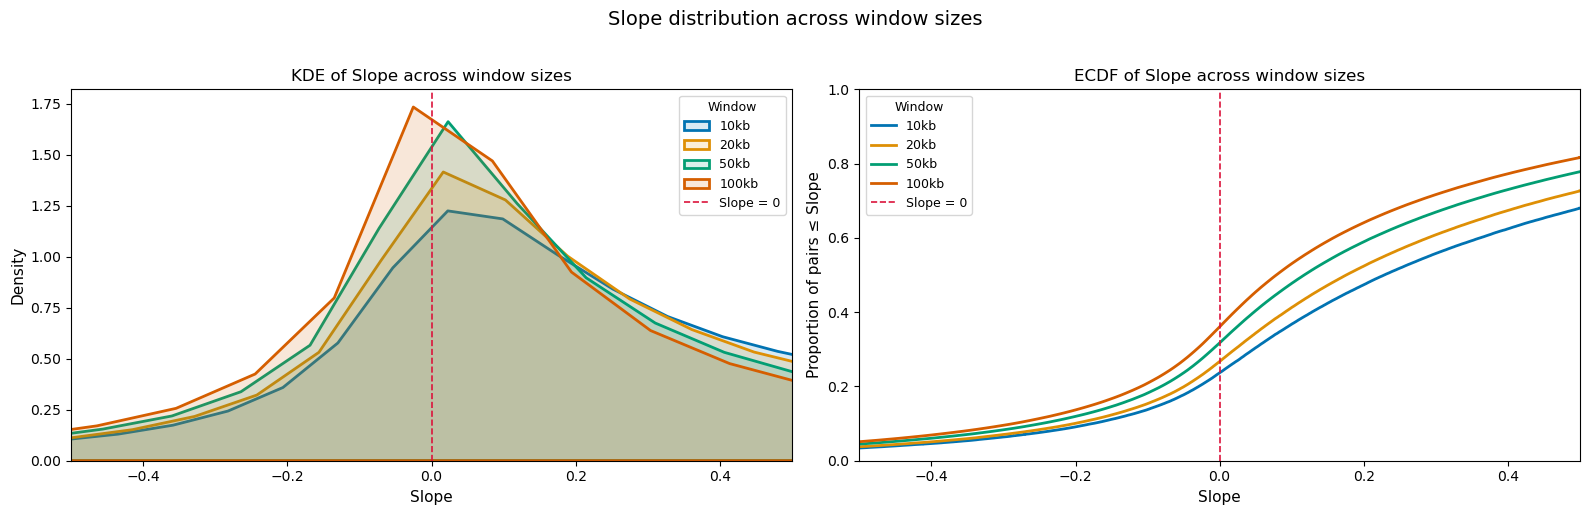

In [4]:
## Plotting slope distribution across windows
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns

window_labels = ["10kb", "20kb", "50kb", "100kb"]

#set x-axis symmetric around 0

# ── KDE + ECDF combined figure ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
palette = sns.color_palette("colorblind", n_colors=4)

# --- left panel: KDE ----------------------------------------------------------
ax_kde = axes[0]
for color, window_label in zip(palette, window_labels):
    subset = lm_res_df[lm_res_df["window"] == window_label]["slope"].dropna()
    sns.kdeplot(subset, ax=ax_kde, label=window_label, color=color,
                linewidth=2.0, fill=True, alpha=0.15)

ax_kde.axvline(0.0, color="crimson", linestyle="--", linewidth=1.2, label="Slope = 0")
ax_kde.set_xlim(-0.5, 0.5)  # adjust as needed based on observed slope range
ax_kde.set_xlabel("Slope", fontsize=11)
ax_kde.set_ylabel("Density", fontsize=11)
ax_kde.set_title("KDE of Slope across window sizes", fontsize=12)
ax_kde.legend(title="Window", fontsize=9, title_fontsize=9)

# --- right panel: ECDF --------------------------------------------------------
ax_ecdf = axes[1]
for color, window_label in zip(palette, window_labels):
    subset = lm_res_df[lm_res_df["window"] == window_label]["slope"].dropna()
    sns.ecdfplot(subset, ax=ax_ecdf, label=window_label, color=color, linewidth=2.0)

ax_ecdf.axvline(0.0, color="crimson", linestyle="--", linewidth=1.2, label="Slope = 0")
ax_ecdf.set_xlim(-0.5, 0.5)  # adjust as needed based on observed slope range
ax_ecdf.set_xlabel("Slope", fontsize=11)
ax_ecdf.set_ylabel("Proportion of pairs ≤ Slope", fontsize=11)
ax_ecdf.set_title("ECDF of Slope across window sizes", fontsize=12)
ax_ecdf.legend(title="Window", fontsize=9, title_fontsize=9)

fig.suptitle("Slope distribution across window sizes", y=1.02, fontsize=14)
plt.tight_layout()

fig.savefig(
    "/home/fgsasse_lrs_1/Downloads/BA/BA_data/Correlations/Graphics/"
    "peak_gene_slope_kde_ecdf_ct.png",
    dpi=300, bbox_inches="tight"
)
plt.show()

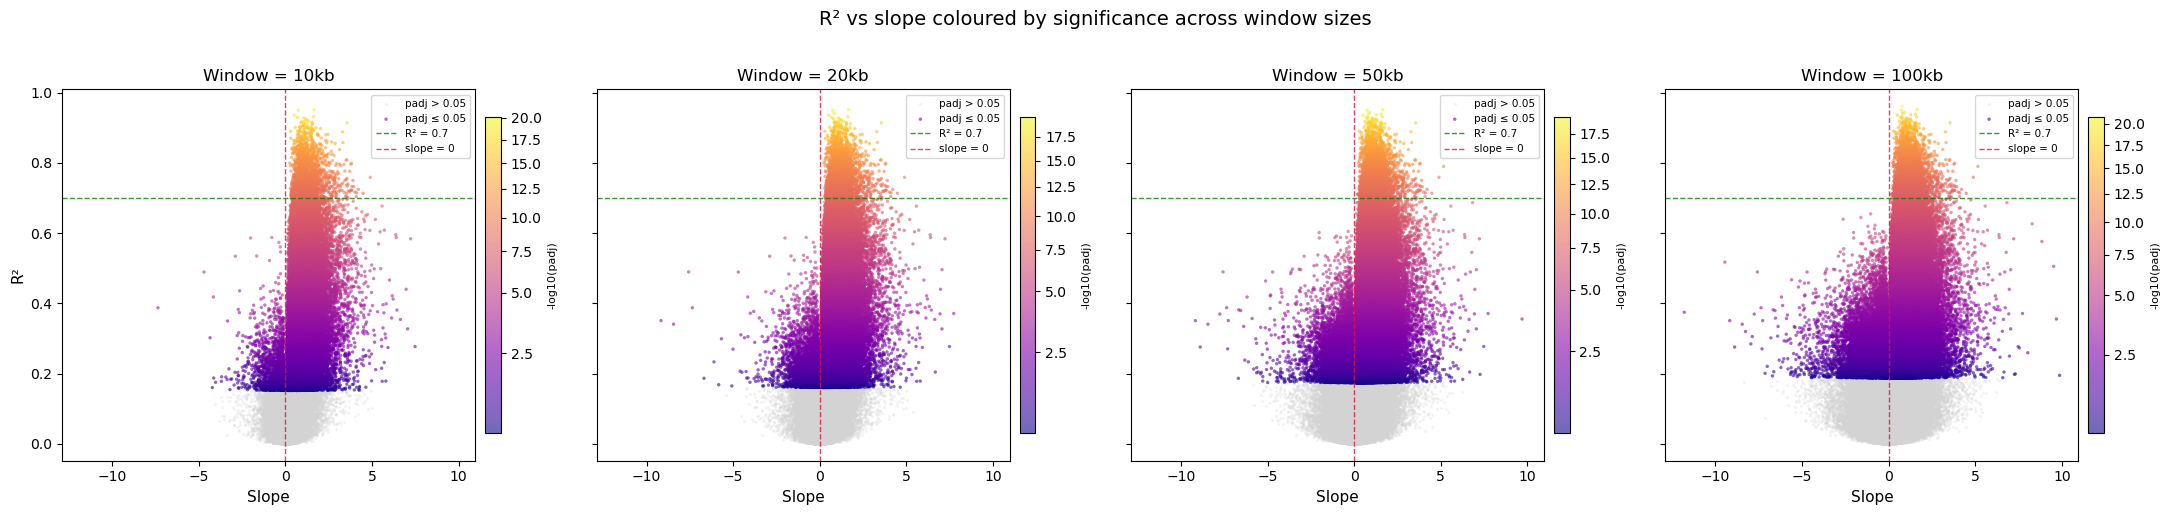

In [5]:
#plotting R^2 vs slope coloured by −log10(padj <= 0.05)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns


window_labels = ["10kb", "20kb", "50kb", "100kb"]

fig, axes = plt.subplots(1, 4, figsize=(22, 5), sharex=True, sharey=True)

for i, (ax, window_label) in enumerate(zip(axes, window_labels)):
    subset = lm_res_df[lm_res_df["window"] == window_label].dropna(
        subset=["slope", "r_squared", "padj"]
    )

    # split into significant and non-significant
    sig     = subset[subset["padj"] <= 0.05]
    non_sig = subset[subset["padj"] >  0.05]

    # non-significant in grey
    ax.scatter(
        non_sig["slope"], non_sig["r_squared"],
        c="lightgrey", s=4, alpha=0.3,
        linewidth=0, rasterized=True, label="padj > 0.05"
    )

    # significant coloured by -log10(padj)
    sc = ax.scatter(
        sig["slope"], sig["r_squared"],
        c=sig["neglog10_padj"],
        cmap="plasma", s=6, alpha=0.6,
        linewidth=0, rasterized=True,
        norm=mcolors.PowerNorm(gamma=0.5),  # compress high values
        label="padj ≤ 0.05"
    )
    cb = fig.colorbar(sc, ax=ax, pad=0.02, shrink=0.85)
    cb.set_label("-log10(padj)", fontsize=8)

    ax.axhline(0.7, color="green", linestyle="--",
               linewidth=1.0, alpha=0.8, label="R² = 0.7")
    ax.axvline(0.0, color="crimson", linestyle="--",
               linewidth=1.0, alpha=0.8, label="slope = 0")
    ax.set_xlabel("Slope", fontsize=11)
    ax.set_ylabel("R²" if i == 0 else "", fontsize=11)
    ax.set_title(f"Window = {window_label}", fontsize=12)
    ax.legend(fontsize=7.5, loc="upper right", frameon=True)

fig.suptitle("R² vs slope coloured by significance across window sizes",
             y=1.02, fontsize=14)
plt.tight_layout()
fig.savefig(
    "/home/fgsasse_lrs_1/Downloads/BA/BA_data/Correlations/Graphics/"
    "peak_gene_r2_slope_padj_ct.png",
    dpi=300, bbox_inches="tight"
)
plt.show()

High R², high slope, bright colour --> Strong, reliable, significant activating peak — top candidate regulatory element
High R², negative slope, bright colour --> Strong repressive relationship — worth investigating
High R², low slope, bright colour --> Peak explains much expression variance but effect per unit accessibility is small — could reflect a highly sensitive regulatory element operating in a narrow accessibility range
Low R², high slope --> Steep but noisy relationship — few data points drive the slope, unreliable
Cluster of grey points at low R² near slope = 0 --> The expected bulk of non-regulatory background peaks

In [15]:
# classify every peak–gene pair into one of three categories and count how many pairs fall into each category per window and gene
def classify_pair(row):
    if row["padj"] <= 0.05 and row["slope"] < 0:
        return "sig. negative"
    elif row["padj"] <= 0.05 and row["slope"] > 0:
        return "sig. positive"
    else:
        return "non-significant"

lm_res_df["category"] = lm_res_df.apply(classify_pair, axis=1)

agg_lm_res_df = (
    lm_res_df
    .dropna(subset=["slope", "padj"])
    .groupby(["window", "gene", "category"])
    .size()
    .reset_index(name="count")
)

agg_lm_res_df.head()

,window,gene,category,count
0,100kb,a1cf,non-significant,87
1,100kb,a1cf,sig. positive,8
2,100kb,a2ml,non-significant,73
3,100kb,a2ml,sig. negative,1
4,100kb,a2ml,sig. positive,3


In [14]:
#count the number of significant peaks and non-significant peaks for each gene in all window sizes in lm_res_df
gene_significance_summary = []
for gene_id in lm_res_df["gene"].unique():
    gene_data = lm_res_df[lm_res_df["gene"] == gene_id]
    for window in window_labels:
        window_data = gene_data[gene_data["window"] == window]
        n_sig_pos = ((window_data["padj"] <= 0.05) & (window_data["slope"] > 0)).sum()
        n_sig_neg = ((window_data["padj"] <= 0.05) & (window_data["slope"] < 0)).sum()
        n_non_sig = ((window_data["padj"] > 0.05) | (window_data["padj"].isna())).sum()

        gene_significance_summary.append({
            "gene": gene_id,
            "window": window,
            "n_sig_pos": n_sig_pos,
            "n_sig_neg": n_sig_neg,
            "n_non_sig": n_non_sig,
            "n_total": len(window_data)
        })
lm_summary_df = pd.DataFrame(gene_significance_summary)
print(lm_summary_df.head())

    gene window  n_sig_pos  n_sig_neg  n_non_sig  n_total
0  rpl24   10kb          0          0         13       13
1  rpl24   20kb          0          0         19       19
2  rpl24   50kb          0          0         31       31
3  rpl24  100kb          0          2         55       57
4  cep97   10kb          3          0         10       13


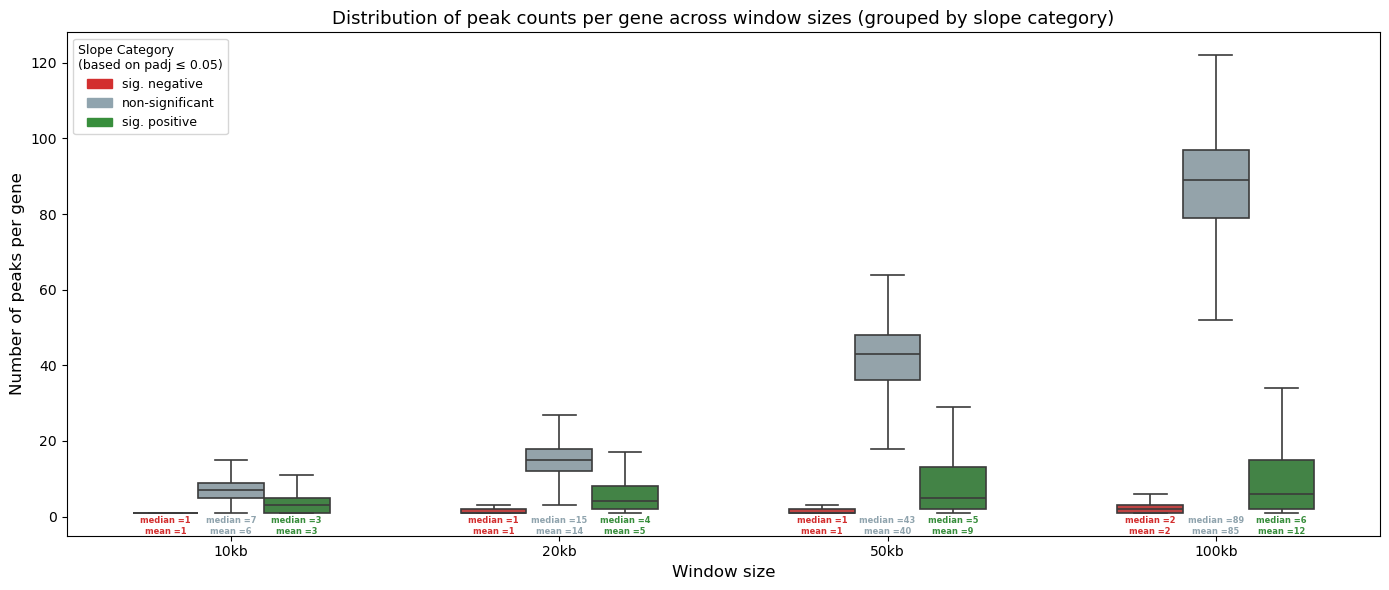

In [ ]:
#Distribution of peak counts per gene across windows (padj ≤ 0.05) per slope category across windows
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import pandas as pd


# ensure plot order is stable
window_labels = ["10kb", "20kb", "50kb", "100kb"]
category_order = ["sig. negative", "non-significant", "sig. positive"]
category_colors = {
    "sig. negative": "#D32F2F",
    "non-significant": "#90A4AE",
    "sig. positive": "#388E3C",
}

# agg_df is already in long format: (window, gene, category, count)
# ensure window is categorical for proper ordering
agg_lm_res_df = agg_lm_res_df.copy()
agg_lm_res_df["window"] = pd.Categorical(
    agg_lm_res_df["window"],
    categories=window_labels,
    ordered=True,
)

# ── plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))

sns.boxplot(
    data=agg_lm_res_df.dropna(subset=["count"]),
    x="window",
    y="count",
    hue="category",
    hue_order=category_order,
    order=window_labels,
    palette=category_colors,
    width=0.6,
    linewidth=1.2,
    flierprops=dict(
        marker=".",
        markersize=1.5,
        alpha=0.2,
        markeredgewidth=0,
    ),
    ax=ax,
)

# annotate median count for each window-category box
n_groups = len(category_order)
total_width = 0.6
box_width = total_width / n_groups

for w_idx, window_label in enumerate(window_labels):
    w_subset = agg_lm_res_df[agg_lm_res_df["window"] == window_label]
    for c_idx, cat in enumerate(category_order):
        vals = w_subset[w_subset["category"] == cat]["count"]
        if vals.empty:
            continue

        x_pos = (
            w_idx
            - total_width / 2
            + box_width / 2
            + c_idx * box_width
        )
        y_med = vals.median()
        y_mean = vals.mean()
        ax.text(
            x=x_pos,
            y=ax.get_ylim()[0] + 0.00001  * (ax.get_ylim()[1] - ax.get_ylim()[0]), # place text slightly above x-axis
            s=f"median ={int(y_med):,}\nmean ={int(y_mean):,}",
            ha="center",
            va="bottom",
            fontsize=6,
            fontweight="bold",
            color=category_colors[cat],
        )

# ── labels + legend ───────────────────────────────────────────────────────────
ax.set_xlabel("Window size", fontsize=12)
ax.set_ylabel("Number of peaks per gene", fontsize=12)
ax.set_title("Distribution of peak counts per gene across window sizes (grouped by slope category)", fontsize=13)

legend_patches = [
    mpatches.Patch(color=category_colors[cat], label=cat)
    for cat in category_order
]
ax.legend(
    handles=legend_patches,
    title="Slope Category\n(based on padj ≤ 0.05)",
    fontsize=9,
    title_fontsize=9,
    frameon=True,
    loc="upper left",
)

plt.tight_layout()

fig.savefig(
    "/home/fgsasse_lrs_1/Downloads/BA/BA_data/Correlations/Graphics/"
    "peak_gene_count_lm_aggregated_ct.png",
    dpi=300, bbox_inches="tight"
)
plt.show()

In [21]:
# Subset the cor_results of all window size dictionaries to only include gene-peak pairs with a significant correlation (p-value <= 0.05)
sig_lm_res_df = lm_res_df[lm_res_df["padj"] <= 0.05].copy()

sig_agg_lm_res_df = (
    lm_res_df
    .dropna(subset=["slope", "padj"])
    .groupby(["window", "gene", "category"])
    .size()
    .reset_index(name="count")
)
sig_agg_lm_res_df.tail()
lm_res_df.head()

,window,gene,peak,slope,intercept,r_squared,stderr,pval,neglog10_pval,padj,neglog10_padj,category
0,10kb,rpl24,1-2372-3057,0.015480,4.137237,0.008876,0.026891,0.568340,0.245392,0.724824,0.139767,non-significant
1,10kb,rpl24,1-3427-4032,-0.025303,4.184215,0.020647,0.028649,0.382828,0.416996,0.565719,0.247399,non-significant
2,10kb,rpl24,1-4469-7268,-0.008327,4.170118,0.001454,0.035874,0.817717,0.087397,0.897746,0.046846,non-significant
3,10kb,rpl24,1-9541-9969,-0.019336,4.181359,0.007738,0.035996,0.594363,0.225948,0.744353,0.128221,non-significant
4,10kb,rpl24,1-11007-12962,0.009661,4.126905,0.000670,0.061335,0.875692,0.057649,0.932150,0.030514,non-significant


In [22]:
lm_res_df.pval.max()

np.float64(0.9999990478317604)

In [ ]:
#Plotting the distribution of the counts of significant peaks across all windows in a boxplot
import numpy as np  
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns   


# 1. Count significant peaks per gene for each window size
sig_counts = sig_lm_res_df.groupby(["window", "gene"]).size().reset_index(name="sig_peak_count")
# 2. Plot boxplot of significant peak counts per gene across window sizes
sns.set_style("whitegrid")
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=sig_counts,
    x="window",
    y="sig_peak_count",
    palette="Set2",
    showfliers=False
)
plt.xlabel("Window size", fontsize=12)
plt.ylabel("Number of significant peaks per gene", fontsize=12)
plt.title("Distribution of significant peak counts per gene across window sizes", fontsize=14)
#plt.yscale("log")  # log scale to handle wide range of counts
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.savefig(
    "/home/fgsasse_lrs_1/Downloads/BA/BA_data/Correlations/Graphics/"
    "significant_peak_counts_per_gene_boxplot_ct.png",
    dpi=300, bbox_inches="tight"
)
plt.show()